### Neste notebook, vamos avaliar na mão como funciona o calculo das distancias utilizadas no knn para ver quais são os vizinhos mais proximos.

In [1]:
import pandas as pd

In [2]:
df = pd.DataFrame({
    'x': [1, 2, 3, 4, 5, 6],
    'y': [1, 1, 2, 3, 3, 4],
    'classe': ['A', 'A', 'A', 'B', 'B', 'B']
})

df

,x,y,classe
0,1,1,A
1,2,1,A
2,3,2,A
3,4,3,B
4,5,3,B
5,6,4,B


### Distância Euclidiana (intuição + fórmula)

A distância euclidiana mede a distância **em linha reta** entre dois pontos.  
No KNN, ela é usada para descobrir quais pontos estão mais próximos de um ponto de consulta.

Para dois pontos em 2D, \(P_1=(x_1, y_1)\) e \(P_2=(x_2, y_2)\):

\[
d(P_1, P_2)=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
\]

---

### Forma geral em \(n\) dimensões

\[
d(\mathbf{p},\mathbf{q})=\sqrt{\sum_{i=1}^{n}(p_i-q_i)^2}
\]

---

### Passo a passo do cálculo (2D)

1. Subtrair as coordenadas em cada eixo: \((x_2-x_1)\) e \((y_2-y_1)\)  
2. Elevar ao quadrado cada diferença  
3. Somar os quadrados  
4. Tirar a raiz quadrada da soma

---

### Exemplo rápido com pontos do nosso `df`

Entre \((1,1)\) e \((3,2)\):

\[
d=\sqrt{(3-1)^2+(2-1)^2}=\sqrt{4+1}=\sqrt{5}\approx 2{,}24
\]

Quanto menor o valor de \(d\), mais próximo é o vizinho.

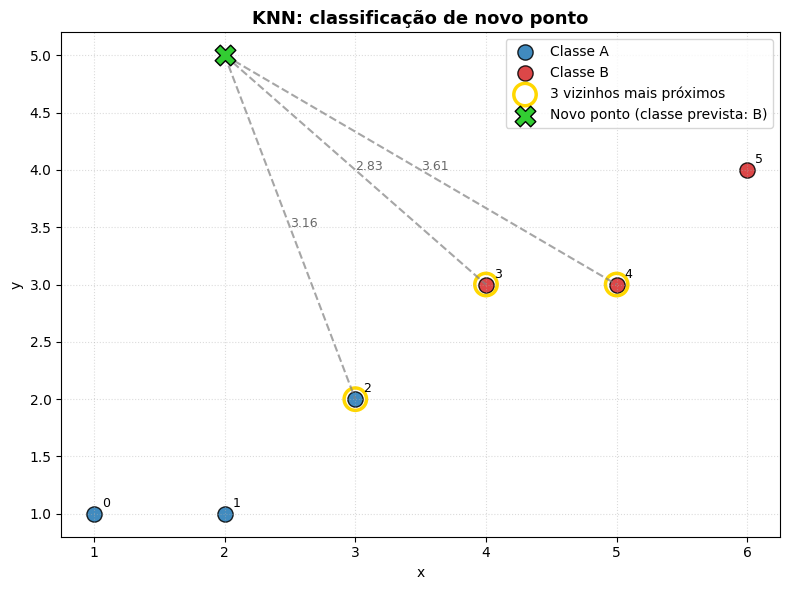

In [13]:
# Entrada do novo ponto
x_in = float(input("Digite x do novo ponto: ").replace(",", "."))
y_in = float(input("Digite y do novo ponto: ").replace(",", "."))

# (Opcional) permitir mudar k
k_in = input(f"Digite k (Enter para usar k={k}): ").strip()
k_plot = int(k_in) if k_in else k

novo_ponto = (x_in, y_in)

# Distâncias euclidianas
distancias_novas = []
for idx, row in df.iterrows():
    d = ((row["x"] - novo_ponto[0])**2 + (row["y"] - novo_ponto[1])**2) ** 0.5
    distancias_novas.append((idx, d, row["classe"]))

# Ordena e pega k vizinhos
distancias_novas.sort(key=lambda x: x[1])
vizinhos_novos = distancias_novas[:k_plot]

# Classe prevista (maioria)
classes_vizinhos = [c for _, _, c in vizinhos_novos]
classe_prevista = pd.Series(classes_vizinhos).value_counts().idxmax()

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

for classe, grupo in df.groupby("classe"):
    ax.scatter(
        grupo["x"], grupo["y"],
        s=120, c=cores.get(classe, "gray"), label=f"Classe {classe}",
        edgecolor="black", alpha=0.85
    )

idx_vizinhos = [i for i, _, _ in vizinhos_novos]
df_vizinhos = df.loc[idx_vizinhos]
ax.scatter(
    df_vizinhos["x"], df_vizinhos["y"],
    s=260, facecolors="none", edgecolors="gold", linewidths=2.5,
    label=f"{k_plot} vizinhos mais próximos"
)

ax.scatter(
    novo_ponto[0], novo_ponto[1],
    s=220, marker="X", c="limegreen", edgecolor="black",
    label=f"Novo ponto (classe prevista: {classe_prevista})", zorder=5
)

for i, dist, _ in vizinhos_novos:
    x_v, y_v = df.loc[i, ["x", "y"]]
    ax.plot([novo_ponto[0], x_v], [novo_ponto[1], y_v], "--", color="gray", alpha=0.7)
    ax.text((novo_ponto[0] + x_v)/2, (novo_ponto[1] + y_v)/2, f"{dist:.2f}", fontsize=9, color="dimgray")

for i, r in df.iterrows():
    ax.text(r["x"] + 0.06, r["y"] + 0.06, str(i), fontsize=9)

ax.set_title("KNN: classificação de novo ponto", fontsize=13, weight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, linestyle=":", alpha=0.45)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

### Distância de Manhattan (fórmula)

A distância de Manhattan mede a distância entre dois pontos somando as diferenças **absolutas** em cada dimensão.  
É como se você andasse apenas em linhas retas (horizontal e vertical), sem diagonais.

Para dois pontos em 2D, \(P_1=(x_1, y_1)\) e \(P_2=(x_2, y_2)\):

\[
d_{Manhattan}(P_1, P_2) = |x_2 - x_1| + |y_2 - y_1|
\]

---

### Forma geral em \(n\) dimensões

\[
d_{Manhattan}(\mathbf{p}, \mathbf{q}) = \sum_{i=1}^{n} |p_i - q_i|
\]

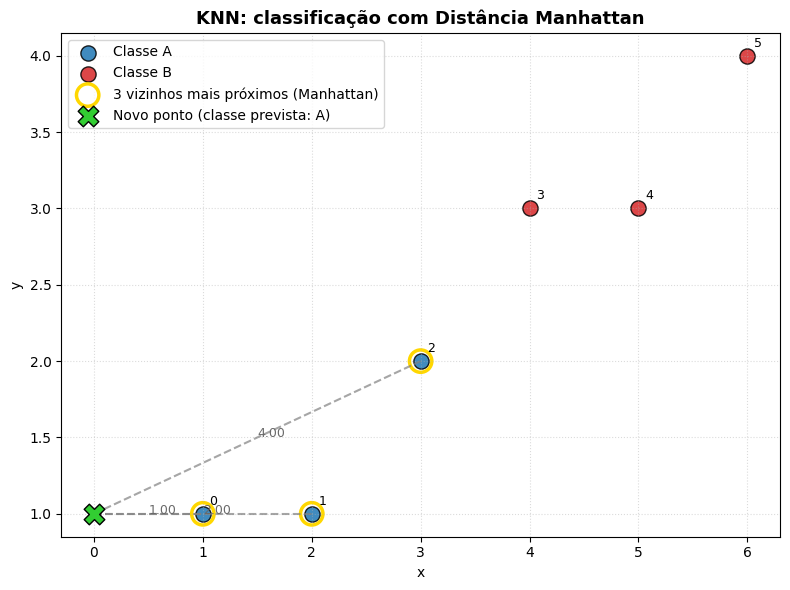

In [18]:
# Entrada do novo ponto
x_in = float(input("Digite x do novo ponto: ").replace(",", "."))
y_in = float(input("Digite y do novo ponto: ").replace(",", "."))

# (Opcional) permitir mudar k
k_in = input(f"Digite k (Enter para usar k={k}): ").strip()
k_plot = int(k_in) if k_in else k

novo_ponto = (x_in, y_in)

# Distâncias Manhattan
distancias_manhattan = []
for idx, row in df.iterrows():
    d = abs(row["x"] - novo_ponto[0]) + abs(row["y"] - novo_ponto[1])
    distancias_manhattan.append((idx, d, row["classe"]))

# Ordena e pega k vizinhos
distancias_manhattan.sort(key=lambda x: x[1])
vizinhos_manhattan = distancias_manhattan[:k_plot]

# Classe prevista (maioria)
classes_vizinhos = [c for _, _, c in vizinhos_manhattan]
classe_prevista = pd.Series(classes_vizinhos).value_counts().idxmax()

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

for classe, grupo in df.groupby("classe"):
    ax.scatter(
        grupo["x"], grupo["y"],
        s=120, c=cores.get(classe, "gray"), label=f"Classe {classe}",
        edgecolor="black", alpha=0.85
    )

idx_vizinhos = [i for i, _, _ in vizinhos_manhattan]
df_vizinhos = df.loc[idx_vizinhos]
ax.scatter(
    df_vizinhos["x"], df_vizinhos["y"],
    s=260, facecolors="none", edgecolors="gold", linewidths=2.5,
    label=f"{k_plot} vizinhos mais próximos (Manhattan)"
)

ax.scatter(
    novo_ponto[0], novo_ponto[1],
    s=220, marker="X", c="limegreen", edgecolor="black",
    label=f"Novo ponto (classe prevista: {classe_prevista})", zorder=5
)

for i, dist, _ in vizinhos_manhattan:
    x_v, y_v = df.loc[i, ["x", "y"]]
    ax.plot([novo_ponto[0], x_v], [novo_ponto[1], y_v], "--", color="gray", alpha=0.7)
    ax.text((novo_ponto[0] + x_v)/2, (novo_ponto[1] + y_v)/2, f"{dist:.2f}", fontsize=9, color="dimgray")

for i, r in df.iterrows():
    ax.text(r["x"] + 0.06, r["y"] + 0.06, str(i), fontsize=9)

ax.set_title("KNN: classificação com Distância Manhattan", fontsize=13, weight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, linestyle=":", alpha=0.45)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()